# Preprocesamiento de Variables Satelitales
**Proyecto Final — Diplomado AI UNI**  

**Autor:** Alvaro Untiveros


Kernel: `dengue-uni`

**Problema identificado:** las variables satelitales se fusionaron sin imputación,
generando ~24% de nulos en NDVI/NDWI/EVI y ~89% en CHIRPS. Los modelos reciben
`fillna(0)` que introduce ruido falso — 0 no significa ausencia de vegetación
o precipitación, sino dato faltante.

**Estrategia de imputación por variable:**

| Variable | Estrategia | Fallback |
|----------|-----------|----------|
| NDVI, NDWI, EVI, índices compuestos | Interpolación lineal temporal por provincia | Media estacional (mes × provincia) |
| LST diurna/nocturna | Interpolación lineal + proxy con `tmean_clima` | Media estacional |
| CHIRPS precip | Interpolación lineal (2023) + proxy con `ptot_clima` CDC | `ptot_clima` directo |
| SRTM altitud/pendiente | Sin nulos — estático, ok | — |

**Salida:** `data/interim/satelital_imputado.parquet`

## 0. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR   = Path('../')
DATA_RAW   = BASE_DIR / 'data' / 'raw'
DATA_INTER = BASE_DIR / 'data' / 'interim'

plt.rcParams.update({'figure.dpi':120, 'figure.figsize':(13,4)})
print('Imports OK ✓')

Imports OK ✓


## 1. Carga de fuentes

In [2]:
# CDC base (para proxy climático)
df_cdc = pd.read_parquet(DATA_INTER / 'dengue_con_tasa.parquet')
df_cdc['ubigeo'] = df_cdc['ubigeo'].astype(str).str.zfill(6)
df_cdc['mes']    = ((df_cdc['semana_epi'] - 1) // 4 + 1).clip(1, 12)

# S2 índices
df_s2 = pd.read_parquet(DATA_INTER / '03_s2_con_ubigeo.parquet')
df_s2['ubigeo'] = df_s2['ubigeo'].astype(str).str.zfill(6)

# LST
df_lst = pd.read_parquet(DATA_INTER / '03_lst_con_ubigeo.parquet')
df_lst['ubigeo'] = df_lst['ubigeo'].astype(str).str.zfill(6)

# CHIRPS
GEE_RAW = DATA_INTER / 'gee_raw'
chirps_files = sorted(GEE_RAW.glob('chirps_*.csv'))
df_chirps = pd.concat(
    [pd.read_csv(f)[['ADM2_CODE','ano','semana_epi','mean']]
     for f in chirps_files], ignore_index=True
).rename(columns={'mean':'precip_chirps_mm'})
mapeo = pd.read_parquet(DATA_INTER / 'mapeo_ubigeo_gaul.parquet')
df_chirps = df_chirps.merge(mapeo[['ubigeo','ADM2_CODE']], on='ADM2_CODE', how='left')
df_chirps['ubigeo'] = df_chirps['ubigeo'].astype(str).str.zfill(6)

# SRTM
df_srtm = pd.read_parquet(DATA_INTER / '03_srtm_con_ubigeo.parquet')
df_srtm['ubigeo'] = df_srtm['ubigeo'].astype(str).str.zfill(6)

print(f'CDC    : {df_cdc.shape}')
print(f'S2     : {df_s2.shape}')
print(f'LST    : {df_lst.shape}')
print(f'CHIRPS : {df_chirps.shape}')
print(f'SRTM   : {df_srtm.shape}')

CDC    : (908980, 21)
S2     : (187110, 15)
LST    : (86940, 8)
CHIRPS : (98280, 5)
SRTM   : (1890, 5)


## 2. Diagnóstico de nulos antes de imputar

Visualizamos la distribución de nulos por variable y mes para entender
el patrón de datos faltantes antes de decidir la estrategia.

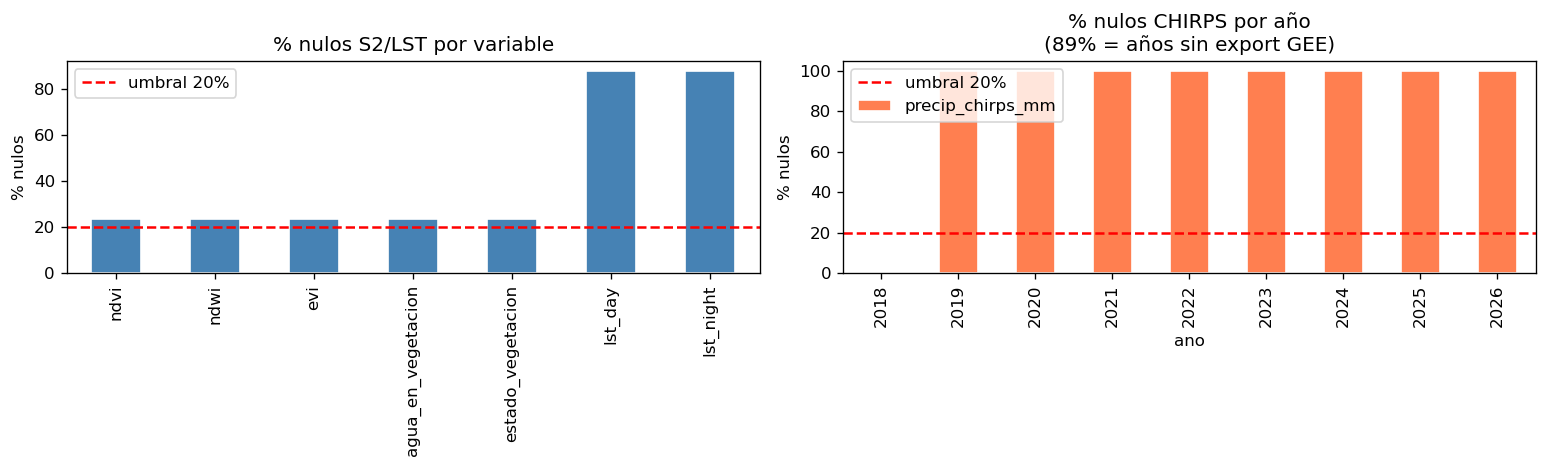

In [3]:
# Cobertura S2 por mes
cols_s2 = ['ndvi','ndwi','evi','agua_en_vegetacion','estado_vegetacion',
           'lst_day','lst_night']
cols_s2 = [c for c in cols_s2 if c in df_s2.columns]

nulos_s2 = df_s2[cols_s2].isnull().mean() * 100

# Cobertura CHIRPS
nulos_chirps_ano = (
    df_cdc.merge(
        df_chirps[['ubigeo','ano','semana_epi','precip_chirps_mm']],
        on=['ubigeo','ano','semana_epi'], how='left'
    )
    .groupby('ano')['precip_chirps_mm']
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nulos_s2.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(20, color='red', linestyle='--', label='umbral 20%')
axes[0].set(title='% nulos S2/LST por variable', ylabel='% nulos')
axes[0].legend()

nulos_chirps_ano.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].axhline(20, color='red', linestyle='--', label='umbral 20%')
axes[1].set(title='% nulos CHIRPS por año\n(89% = años sin export GEE)',
            ylabel='% nulos')
axes[1].legend()
plt.tight_layout()

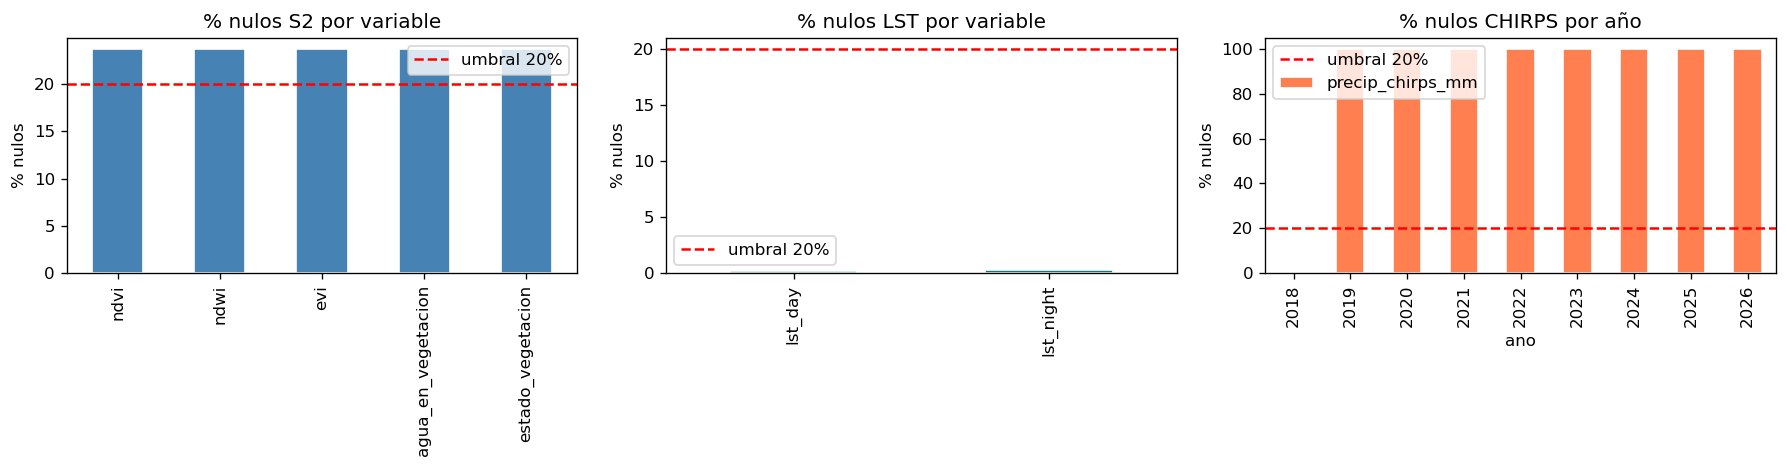

In [6]:
# Cobertura S2 (mensual)
cols_s2_diag = [c for c in ['ndvi','ndwi','evi','agua_en_vegetacion','estado_vegetacion']
                if c in df_s2.columns]
nulos_s2 = df_s2[cols_s2_diag].isnull().mean() * 100

# Cobertura LST (semanal) — separado de S2
cols_lst_diag = [c for c in ['lst_day','lst_night'] if c in df_lst.columns]
nulos_lst = df_lst[cols_lst_diag].isnull().mean() * 100

# Cobertura CHIRPS
nulos_chirps_ano = (
    df_cdc.merge(
        df_chirps[['ubigeo','ano','semana_epi','precip_chirps_mm']],
        on=['ubigeo','ano','semana_epi'], how='left'
    )
    .groupby('ano')['precip_chirps_mm']
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

nulos_s2.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(20, color='red', linestyle='--', label='umbral 20%')
axes[0].set(title='% nulos S2 por variable', ylabel='% nulos')
axes[0].legend()

nulos_lst.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].axhline(20, color='red', linestyle='--', label='umbral 20%')
axes[1].set(title='% nulos LST por variable', ylabel='% nulos')
axes[1].legend()

nulos_chirps_ano.plot(kind='bar', ax=axes[2], color='coral', edgecolor='white')
axes[2].axhline(20, color='red', linestyle='--', label='umbral 20%')
axes[2].set(title='% nulos CHIRPS por año', ylabel='% nulos')
axes[2].legend()

plt.tight_layout()

## 3. Imputación S2 — NDVI, NDWI, EVI, índices compuestos

**Estrategia en 2 pasos:**

1. Interpolación lineal temporal dentro de cada provincia (`ubigeo` + `ADM2_CODE`)
2. Para nulos que quedan (extremos de serie): media estacional por mes × ADM2_CODE

In [7]:
def imputar_serie_temporal(df, group_col, time_col, value_cols):
    """
    Imputa nulos en value_cols con interpolación lineal por grupo,
    luego rellena extremos con media estacional (mes).
    """
    df = df.sort_values([group_col, time_col]).copy()

    # Paso 1: interpolación lineal por grupo
    for col in value_cols:
        df[col] = (
            df.groupby(group_col)[col]
            .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
        )

    return df


def imputar_media_estacional(df, group_cols, time_col, value_cols):
    """
    Rellena nulos restantes con la media del mismo mes × grupo.
    """
    df = df.copy()
    if 'mes' not in df.columns and time_col == 'mes':
        df['mes'] = df[time_col]

    for col in value_cols:
        media_est = df.groupby(group_cols + ['mes'])[col].transform('mean')
        df[col] = df[col].fillna(media_est)

    return df


# Imputar S2
cols_imputar_s2 = [c for c in ['ndvi','ndwi','evi','agua_en_vegetacion',
                                'agua_expuesta','estado_vegetacion',
                                'lst_day','lst_night','seq_lst_norm','hum_adj_veg']
                   if c in df_s2.columns]

print('Imputando S2 — paso 1: interpolación temporal...')
df_s2_imp = imputar_serie_temporal(df_s2, 'ADM2_CODE', 'mes', cols_imputar_s2)

print('Imputando S2 — paso 2: media estacional...')
df_s2_imp = imputar_media_estacional(df_s2_imp, ['ADM2_CODE'], 'mes', cols_imputar_s2)

nulos_post = df_s2_imp[cols_imputar_s2].isnull().mean() * 100
print('\nNulos S2 post-imputación:')
print(nulos_post.round(2).to_string())

Imputando S2 — paso 1: interpolación temporal...
Imputando S2 — paso 2: media estacional...

Nulos S2 post-imputación:
ndvi                   0.00
ndwi                   0.00
evi                    0.00
agua_en_vegetacion     0.00
agua_expuesta          0.00
estado_vegetacion      0.00
lst_day                0.00
lst_night              0.00
seq_lst_norm           0.00
hum_adj_veg           10.48


## 4. Imputación LST

LST tiene datos semanales pero con huecos por nubes (composición 8 días MODIS).
Donde LST falta completamente usamos `tmean_clima` del CDC como proxy lineal:

$$LST_{proxy} = a \cdot tmean\_clima + b$$

El coeficiente se estima por regresión sobre los datos donde ambos existen.

In [8]:
from sklearn.linear_model import LinearRegression

# Fusionar LST con tmean_clima del CDC para calibrar proxy
df_lst_cal = df_lst.merge(
    df_cdc[['ubigeo','ano','semana_epi','tmean_clima']]
    .drop_duplicates(),
    on=['ubigeo','ano','semana_epi'], how='left'
)

# Calibrar proxy LST ~ tmean_clima donde ambos tienen dato
mask_cal = df_lst_cal['lst_day'].notna() & df_lst_cal['tmean_clima'].notna()
X_cal = df_lst_cal.loc[mask_cal, 'tmean_clima'].values.reshape(-1, 1)
y_cal = df_lst_cal.loc[mask_cal, 'lst_day'].values

reg = LinearRegression().fit(X_cal, y_cal)
print(f'LST_proxy = {reg.coef_[0]:.3f} × tmean_clima + {reg.intercept_:.3f}')
print(f'R² calibración: {reg.score(X_cal, y_cal):.3f}')

# Rellenar LST faltante con proxy
mask_falta = df_lst_cal['lst_day'].isna() & df_lst_cal['tmean_clima'].notna()
df_lst_cal.loc[mask_falta, 'lst_day'] = reg.predict(
    df_lst_cal.loc[mask_falta, 'tmean_clima'].values.reshape(-1, 1)
)

# LST nocturna: mismo approach con tmin_clima
if 'tmin_clima' in df_cdc.columns:
    df_lst_cal = df_lst_cal.merge(
        df_cdc[['ubigeo','ano','semana_epi','tmin_clima']].drop_duplicates(),
        on=['ubigeo','ano','semana_epi'], how='left'
    )
    mask_n = df_lst_cal['lst_night'].isna() & df_lst_cal['tmin_clima'].notna()
    if mask_n.sum() > 0:
        mask_cal_n = df_lst_cal['lst_night'].notna() & df_lst_cal['tmin_clima'].notna()
        reg_n = LinearRegression().fit(
            df_lst_cal.loc[mask_cal_n,'tmin_clima'].values.reshape(-1,1),
            df_lst_cal.loc[mask_cal_n,'lst_night'].values
        )
        df_lst_cal.loc[mask_n,'lst_night'] = reg_n.predict(
            df_lst_cal.loc[mask_n,'tmin_clima'].values.reshape(-1,1)
        )

# Interpolación para los que quedan
for col in ['lst_day','lst_night']:
    if col in df_lst_cal.columns:
        df_lst_cal[col] = (
            df_lst_cal.groupby('ubigeo')[col]
            .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
        )

nulos_lst = df_lst_cal[['lst_day','lst_night']].isnull().mean() * 100
print(f'\nNulos LST post-imputación:')
print(nulos_lst.round(2).to_string())

LST_proxy = 0.565 × tmean_clima + 17.793
R² calibración: 0.239

Nulos LST post-imputación:
lst_day      0.0
lst_night    0.0


## 5. Imputación CHIRPS

CHIRPS tiene datos solo para 2023 (~11% del período total 2018-2026).
Para los años sin export GEE usamos `ptot_clima` del CDC como proxy.

Calibramos la relación entre ambas fuentes donde se solapan (2023),
luego aplicamos el proxy para el resto.

In [9]:
# Fusionar CHIRPS con ptot_clima del CDC
df_precip = df_cdc[['ubigeo','ano','semana_epi','ptot_clima']].copy()
df_precip = df_precip.merge(
    df_chirps[['ubigeo','ano','semana_epi','precip_chirps_mm']],
    on=['ubigeo','ano','semana_epi'], how='left'
)

# Calibrar CHIRPS ~ ptot_clima (solo donde ambos tienen dato)
mask_cal = (df_precip['precip_chirps_mm'].notna() &
            df_precip['ptot_clima'].notna())
print(f'Pares para calibración: {mask_cal.sum():,}')

if mask_cal.sum() > 100:
    X_p = df_precip.loc[mask_cal,'ptot_clima'].values.reshape(-1,1)
    y_p = df_precip.loc[mask_cal,'precip_chirps_mm'].values
    reg_p = LinearRegression().fit(X_p, y_p)
    print(f'precip_proxy = {reg_p.coef_[0]:.3f} × ptot_clima + {reg_p.intercept_:.3f}')
    print(f'R² calibración: {reg_p.score(X_p, y_p):.3f}')

    # Rellenar años sin CHIRPS con proxy calibrado
    mask_falta = (df_precip['precip_chirps_mm'].isna() &
                  df_precip['ptot_clima'].notna())
    df_precip.loc[mask_falta,'precip_chirps_mm'] = reg_p.predict(
        df_precip.loc[mask_falta,'ptot_clima'].values.reshape(-1,1)
    ).clip(0)  # precipitación no puede ser negativa
else:
    # Sin calibración suficiente: usar ptot_clima directamente
    print('Usando ptot_clima como proxy directo (sin calibración)')
    df_precip['precip_chirps_mm'] = df_precip['precip_chirps_mm'].fillna(
        df_precip['ptot_clima']
    )

cobertura_post = df_precip['precip_chirps_mm'].notna().mean() * 100
print(f'\nCobertura CHIRPS post-imputación: {cobertura_post:.1f}%')

Pares para calibración: 100,516
precip_proxy = 1.779 × ptot_clima + 5.858
R² calibración: 0.432

Cobertura CHIRPS post-imputación: 100.0%


## 6. Construcción del dataset satelital imputado

In [10]:
# Base: panel completo CDC (ubigeo × ano × semana_epi)
panel = df_cdc[['ubigeo','ano','semana_epi']].drop_duplicates().copy()
panel['mes'] = ((panel['semana_epi'] - 1) // 4 + 1).clip(1, 12)

# Merge S2 imputado (mensual)
cols_s2_out = ['ubigeo','ano','mes'] + cols_imputar_s2
panel = panel.merge(
    df_s2_imp[cols_s2_out].drop_duplicates(['ubigeo','ano','mes']),
    on=['ubigeo','ano','mes'], how='left'
)

# Merge LST imputado (semanal)
cols_lst_out = ['ubigeo','ano','semana_epi','lst_day','lst_night']
cols_lst_out = [c for c in cols_lst_out if c in df_lst_cal.columns]
panel = panel.merge(
    df_lst_cal[cols_lst_out].drop_duplicates(['ubigeo','ano','semana_epi']),
    on=['ubigeo','ano','semana_epi'], how='left'
)

# Merge CHIRPS imputado (semanal)
panel = panel.merge(
    df_precip[['ubigeo','ano','semana_epi','precip_chirps_mm']]
    .drop_duplicates(['ubigeo','ano','semana_epi']),
    on=['ubigeo','ano','semana_epi'], how='left'
)

# Merge SRTM (estático)
df_srtm['ubigeo'] = df_srtm['ubigeo'].astype(str).str.zfill(6)
panel = panel.merge(
    df_srtm[['ubigeo','altitud','pendiente']].drop_duplicates('ubigeo'),
    on='ubigeo', how='left'
)

print(f'Panel satelital imputado: {panel.shape}')
print(f'\nCobertura por variable:')
cols_sat = cols_imputar_s2 + ['lst_day','lst_night','precip_chirps_mm','altitud','pendiente']
cols_sat = [c for c in cols_sat if c in panel.columns]
cob = (panel[cols_sat].notna().mean() * 100).round(1)
print(cob.to_string())

Panel satelital imputado: (888770, 19)

Cobertura por variable:
ndvi                   91.4
ndwi                   91.4
evi                    91.4
agua_en_vegetacion     91.4
agua_expuesta          91.4
estado_vegetacion      91.4
seq_lst_norm           91.4
hum_adj_veg            81.9
precip_chirps_mm      100.0
altitud                99.9
pendiente              99.9


## 7. Verificación visual de la imputación

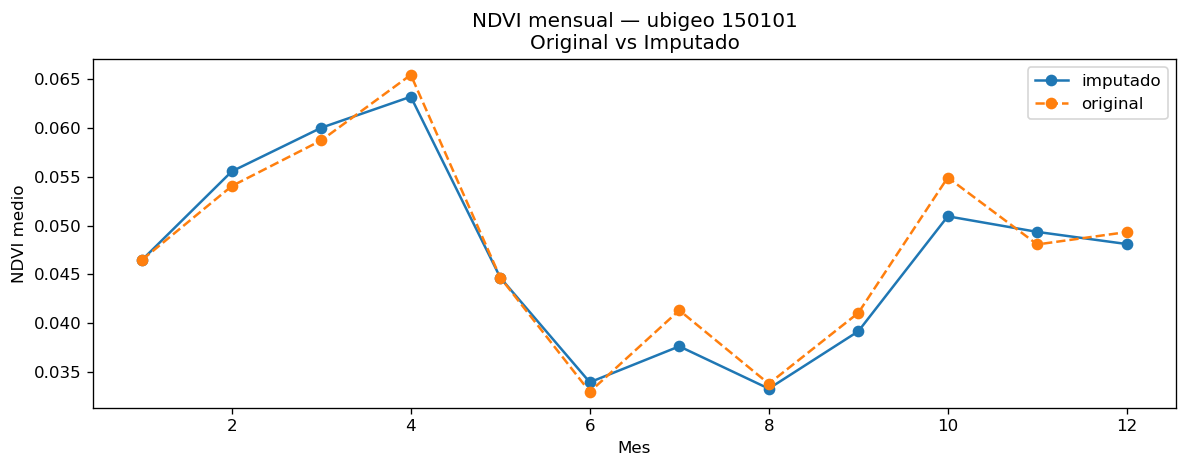

In [11]:
# Comparar NDVI original vs imputado para una provincia
prov_ejemplo = df_s2['ADM2_CODE'].value_counts().index[0]
ubigeos_prov = mapeo[mapeo['ADM2_CODE']==prov_ejemplo]['ubigeo'].tolist()

if ubigeos_prov:
    ub = ubigeos_prov[0]
    orig = df_s2[df_s2['ubigeo']==ub][['mes','ndvi']].copy()
    orig['tipo'] = 'original'
    imp  = panel[panel['ubigeo']==ub][['mes','ndvi']].copy()
    imp['tipo'] = 'imputado'

    fig, ax = plt.subplots(figsize=(10,4))
    for tipo, g in pd.concat([orig,imp]).groupby('tipo'):
        g_mes = g.groupby('mes')['ndvi'].mean()
        ax.plot(g_mes, marker='o', label=tipo,
                linestyle='--' if tipo=='original' else '-')
    ax.set(title=f'NDVI mensual — ubigeo {ub}\nOriginal vs Imputado',
           xlabel='Mes', ylabel='NDVI medio')
    ax.legend()
    plt.tight_layout()

## 8. Guardar dataset satelital imputado

In [12]:
out_path = DATA_INTER / 'satelital_imputado.parquet'
panel.to_parquet(out_path, index=False)
print(f'✓ Guardado: {out_path}')
print(f'  Shape : {panel.shape}')
print(f'  Columnas: {panel.columns.tolist()}')

✓ Guardado: D:\Universidad\Alvaro\Proyecto UNI\UNI\Proyecto\data\interim\satelital_imputado.parquet
  Shape : (888770, 19)
  Columnas: ['ubigeo', 'ano', 'semana_epi', 'mes', 'ndvi', 'ndwi', 'evi', 'agua_en_vegetacion', 'agua_expuesta', 'estado_vegetacion', 'lst_day_x', 'lst_night_x', 'seq_lst_norm', 'hum_adj_veg', 'lst_day_y', 'lst_night_y', 'precip_chirps_mm', 'altitud', 'pendiente']
